In [2]:
!pip install seaborn matplotlib numpy pandas

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [4]:
np.random.seed(42)
n = 50000

# Latent factors
monsoon_factor = np.random.uniform(0, 1, n)
infra_factor   = np.random.uniform(0, 1, n)
human_factor   = np.random.uniform(0, 1, n)

# Positive correlated features
MonsoonIntensity       = np.clip(0.7*monsoon_factor + 0.3*np.random.uniform(0,1,n), 0, 1)
ClimateChange          = np.clip(0.5*monsoon_factor + 0.5*np.random.uniform(0,1,n), 0, 1)
Deforestation          = np.clip(0.4*human_factor   + 0.6*np.random.uniform(0,1,n), 0, 1)
Urbanization           = np.clip(0.4*human_factor   + 0.6*np.random.uniform(0,1,n), 0, 1)
Siltation              = np.clip(0.3*human_factor   + 0.7*np.random.uniform(0,1,n), 0, 1)
Landslides             = np.clip(0.4*monsoon_factor  + 0.6*np.random.uniform(0,1,n), 0, 1)
PopulationScore        = np.clip(0.3*human_factor   + 0.7*np.random.uniform(0,1,n), 0, 1)
DeterioratingInfra     = np.clip(0.4*infra_factor   + 0.6*np.random.uniform(0,1,n), 0, 1)

# Negative correlated features
DamsQuality            = np.clip(0.6*(1-infra_factor) + 0.4*np.random.uniform(0,1,n), 0, 1)
DrainageSystems        = np.clip(0.5*(1-infra_factor) + 0.5*np.random.uniform(0,1,n), 0, 1)
RiverManagement        = np.clip(0.4*(1-infra_factor) + 0.6*np.random.uniform(0,1,n), 0, 1)
TopographyDrainage     = np.clip(0.3*(1-infra_factor) + 0.7*np.random.uniform(0,1,n), 0, 1)
Watersheds             = np.clip(0.3*(1-infra_factor) + 0.7*np.random.uniform(0,1,n), 0, 1)
InactiveDisaster       = np.clip(0.3*(1-infra_factor) + 0.7*np.random.uniform(0,1,n), 0, 1)

# Target
flood_score = (
     0.25 * MonsoonIntensity +
     0.15 * ClimateChange +
     0.12 * Deforestation +
     0.10 * Urbanization +
     0.08 * Siltation +
     0.08 * Landslides +
    -0.20 * DamsQuality +
    -0.15 * DrainageSystems +
    -0.12 * RiverManagement +
    -0.10 * Watersheds +
     0.07 * PopulationScore +
     0.06 * DeterioratingInfra +
     np.random.normal(0, 0.05, n)
)
FloodProbability = (flood_score - flood_score.min()) / (flood_score.max() - flood_score.min())

# Build DataFrame
df = pd.DataFrame({
    'MonsoonIntensity':              MonsoonIntensity,
    'TopographyDrainage':            TopographyDrainage,
    'RiverManagement':               RiverManagement,
    'Deforestation':                 Deforestation,
    'Urbanization':                  Urbanization,
    'ClimateChange':                 ClimateChange,
    'DamsQuality':                   DamsQuality,
    'Siltation':                     Siltation,
    'DrainageSystems':               DrainageSystems,
    'Landslides':                    Landslides,
    'Watersheds':                    Watersheds,
    'DeterioratingInfrastructure':   DeterioratingInfra,
    'PopulationScore':               PopulationScore,
    'InactiveDisasterPreparedness':  InactiveDisaster,
    'FloodProbability':              FloodProbability
})

df.to_csv('flood_dataset.csv', index=False)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 15)


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,DrainageSystems,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,InactiveDisasterPreparedness,FloodProbability
0,0.282942,0.666883,0.530154,0.794922,0.326544,0.328564,0.306379,0.389490,0.077405,0.683188,0.424095,0.518361,0.669354,0.374915,0.586279
1,0.841209,0.760983,0.581492,0.254755,0.268094,0.704695,0.486101,0.419164,0.354667,0.569714,0.537897,0.503505,0.254101,0.585911,0.541164
2,0.752056,0.267936,0.777523,0.252243,0.223178,0.415605,0.819579,0.282251,0.871840,0.323943,0.620626,0.464551,0.264832,0.806995,0.321958
3,0.648403,0.753206,0.622455,0.586968,0.481379,0.522748,0.347953,0.618552,0.353542,0.791310,0.103090,0.889962,0.317271,0.222439,0.657095
4,0.360432,0.688317,0.440575,0.406865,0.676759,0.179550,0.449092,0.474656,0.351824,0.324164,0.592954,0.584697,0.796822,0.182957,0.465561


In [5]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nBasic Statistics:")
df.describe().round(3)

Shape: (50000, 15)

Data Types:
 MonsoonIntensity                float64
TopographyDrainage              float64
RiverManagement                 float64
Deforestation                   float64
Urbanization                    float64
ClimateChange                   float64
DamsQuality                     float64
Siltation                       float64
DrainageSystems                 float64
Landslides                      float64
Watersheds                      float64
DeterioratingInfrastructure     float64
PopulationScore                 float64
InactiveDisasterPreparedness    float64
FloodProbability                float64
dtype: object

Basic Statistics:


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,DrainageSystems,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,InactiveDisasterPreparedness,FloodProbability
count,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000
mean,0.499,0.500,0.501,0.501,0.500,0.500,0.499,0.500,0.500,0.500,0.500,0.501,0.502,0.502,0.504
std,0.220,0.220,0.208,0.208,0.208,0.203,0.208,0.220,0.203,0.208,0.219,0.208,0.220,0.220,0.136
min,0.001,0.004,0.002,0.005,0.003,0.004,0.002,0.005,0.005,0.003,0.000,0.002,0.003,0.001,0.000
25%,0.325,0.325,0.346,0.349,0.345,0.355,0.346,0.324,0.352,0.346,0.325,0.346,0.328,0.328,0.410
50%,0.500,0.501,0.501,0.502,0.500,0.500,0.499,0.499,0.500,0.501,0.499,0.501,0.503,0.503,0.504
75%,0.674,0.673,0.654,0.654,0.654,0.643,0.653,0.675,0.644,0.653,0.676,0.655,0.676,0.677,0.598
max,0.996,0.998,0.998,0.997,0.998,1.000,0.997,0.996,0.998,0.999,0.998,0.996,0.998,0.999,1.000


In [6]:
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing Values:
MonsoonIntensity                0
TopographyDrainage              0
RiverManagement                 0
Deforestation                   0
Urbanization                    0
ClimateChange                   0
DamsQuality                     0
Siltation                       0
DrainageSystems                 0
Landslides                      0
Watersheds                      0
DeterioratingInfrastructure     0
PopulationScore                 0
InactiveDisasterPreparedness    0
FloodProbability                0
dtype: int64

Total missing: 0


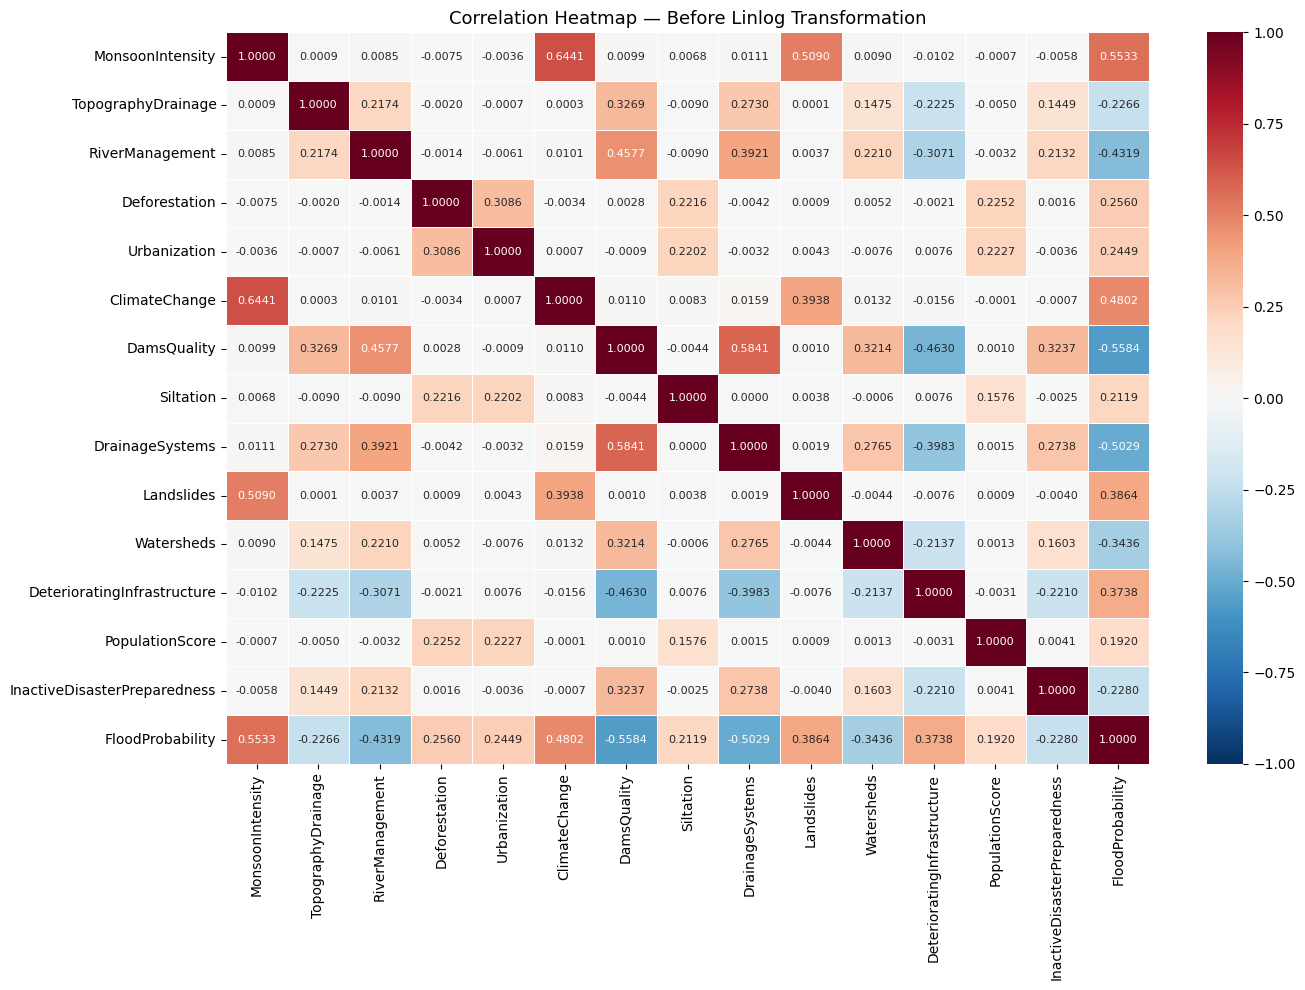

In [7]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.corr(),
    annot=True, fmt='.4f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap — Before Linlog Transformation', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
df_linlog = df.copy()

features = df.columns.drop('FloodProbability')
for col in features:
    df_linlog[col] = np.log1p(df[col])

# FloodProbability stays linear
df_linlog['FloodProbability'] = df['FloodProbability']

print("Linlog transformation applied!")
print("Features transformed:", list(features))
print("FloodProbability: unchanged")
df_linlog.head()

Linlog transformation applied!
Features transformed: ['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'DrainageSystems', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'InactiveDisasterPreparedness']
FloodProbability: unchanged


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,DrainageSystems,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,InactiveDisasterPreparedness,FloodProbability
0,0.249156,0.510955,0.425369,0.584961,0.282577,0.284099,0.267260,0.328937,0.074556,0.520690,0.353537,0.417631,0.512437,0.318392,0.586279
1,0.610422,0.565872,0.458369,0.226941,0.237515,0.533386,0.396156,0.350068,0.303555,0.450893,0.430416,0.407799,0.226419,0.461159,0.541164
2,0.560790,0.237390,0.575221,0.224936,0.201453,0.347557,0.598605,0.248617,0.626922,0.280615,0.482812,0.381549,0.234939,0.591665,0.321958
3,0.499807,0.561446,0.483941,0.461825,0.392973,0.420516,0.298587,0.481532,0.302725,0.582947,0.098115,0.636557,0.275562,0.200848,0.657095
4,0.307802,0.523732,0.365042,0.341364,0.516863,0.165133,0.370937,0.388425,0.301455,0.280781,0.465590,0.460393,0.586019,0.168018,0.465561


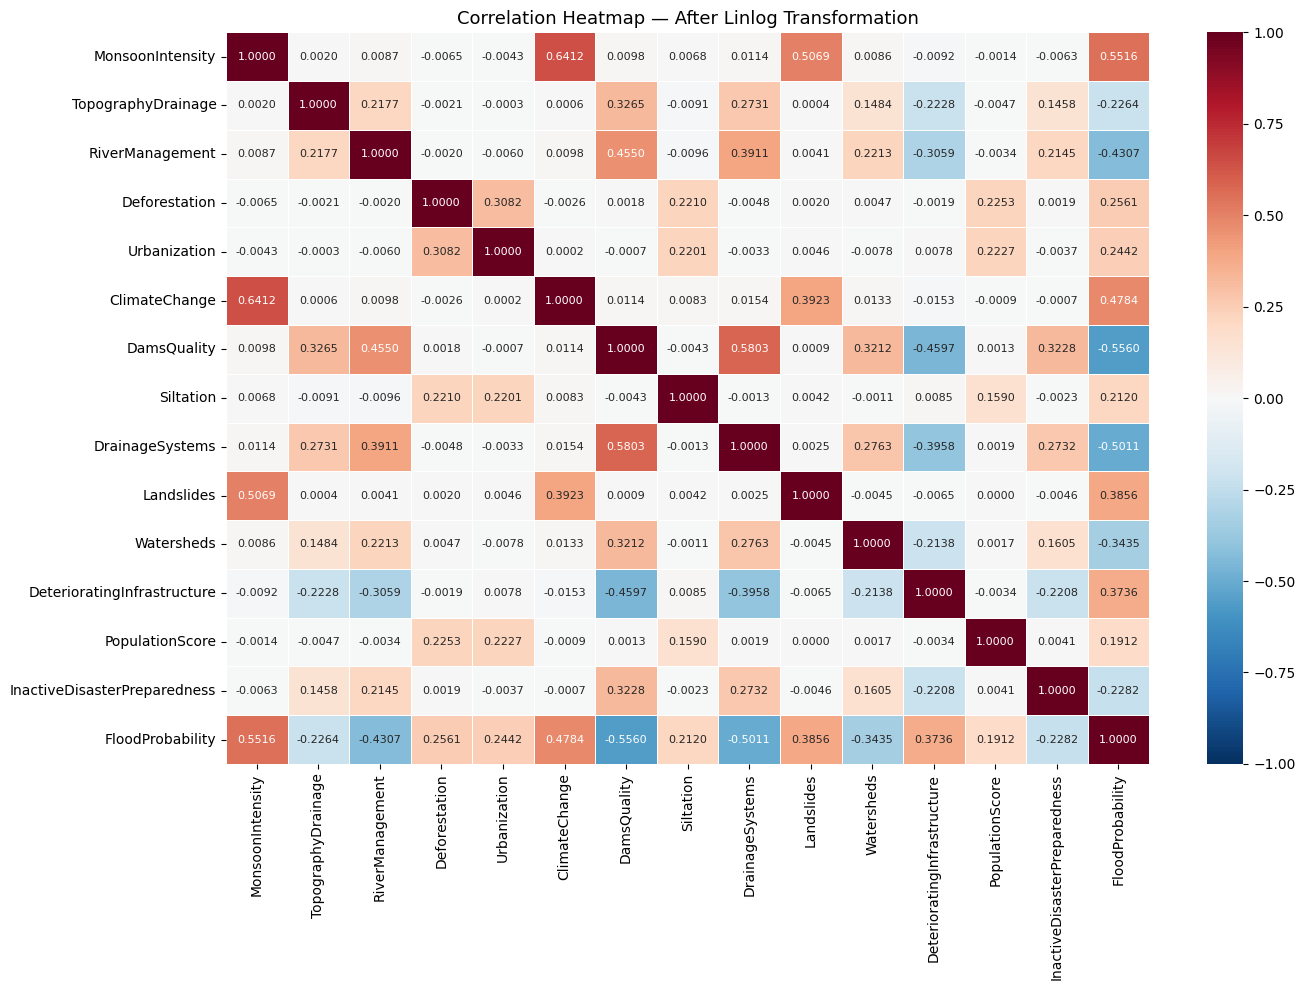

In [9]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_linlog.corr(),
    annot=True, fmt='.4f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap — After Linlog Transformation', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
df_linlog.to_csv('flood_dataset_clean.csv', index=False)
print("Clean dataset saved!")
print(f"Final shape: {df_linlog.shape}")
print(f"\nFloodProbability range: {df_linlog['FloodProbability'].min():.3f} to {df_linlog['FloodProbability'].max():.3f}")

Clean dataset saved!
Final shape: (50000, 15)

FloodProbability range: 0.000 to 1.000


In [11]:

df_linlog.to_csv("../data/flood_dataset_clean.csv", index=False)